In [1]:
# Importing all the requried library 
import pandas as pd
from pathlib import Path
import seaborn as sns
from matplotlib import pyplot as plt
import math
import random
from PIL import Image
import numpy as np

In [2]:
data = '/kaggle/input/plantvillage-dataset/'

In [3]:
# The original dataset has 3 subfolders with each folder having same image but with different style which are colored, grayscaled and segmeneted image
data_1 = data + 'color'
data_2 = data + 'grayscale'
data_3 = data + 'segmented'

In [4]:
# Conveting all datasets in dataframes
paths_1 = [path.parts[-2:] for path in Path(data_1).rglob('*.*')]
paths_2 = [path.parts[-2:] for path in Path(data_2).rglob('*.*')]
paths_3 = [path.parts[-2:] for path in Path(data_3).rglob('*.*')]

In [5]:
df_color = pd.DataFrame(data=paths_1, columns=['Class','Images'])
df_grayscale = pd.DataFrame(data=paths_2, columns=['Class','Images'])
df_segmented = pd.DataFrame(data=paths_3, columns =['Class','Images'])

In [6]:
df_color
# we will work do EDA on color dataset because it best to use for future use

,Class,Images
0,Tomato___Late_blight,781e93a9-2059-42de-8075-658033a6abf7___RS_Late...
1,Tomato___Late_blight,283ff0be-6e5e-4b4e-bf21-639780b77ffc___GHLB2 L...
2,Tomato___Late_blight,0db85707-41f9-42df-ba3b-842d14f00a68___GHLB2 L...
3,Tomato___Late_blight,078a999d-6e6f-427e-a1e6-80b4d2df2bae___GHLB2 L...
4,Tomato___Late_blight,3dcee9ed-43bb-45a9-8cff-641b3dd62179___RS_Late...
...,...,...
54300,Corn_(maize)___healthy,8cdec02e-6273-452f-8681-1319a74d3698___R.S_HL ...
54301,Corn_(maize)___healthy,c9c333a8-30ed-4163-adf1-c65379dac7ac___R.S_HL ...
54302,Corn_(maize)___healthy,85581bfb-0508-4cea-a76c-b929fea867a1___R.S_HL ...
54303,Corn_(maize)___healthy,0b703646-9307-401b-bd31-ace32353d467___R.S_HL ...


In [7]:
# Looking at the folder name (class), identified that abc___xyz naming convenction is used where abc is plant name and xyz is state or diesase, so added 2 extra columns for same by breaking it.
df_color[['plant','state']] = df_color['Class'].str.split('___', expand=True)
df_color

,Class,Images,plant,state
0,Tomato___Late_blight,781e93a9-2059-42de-8075-658033a6abf7___RS_Late...,Tomato,Late_blight
1,Tomato___Late_blight,283ff0be-6e5e-4b4e-bf21-639780b77ffc___GHLB2 L...,Tomato,Late_blight
2,Tomato___Late_blight,0db85707-41f9-42df-ba3b-842d14f00a68___GHLB2 L...,Tomato,Late_blight
3,Tomato___Late_blight,078a999d-6e6f-427e-a1e6-80b4d2df2bae___GHLB2 L...,Tomato,Late_blight
4,Tomato___Late_blight,3dcee9ed-43bb-45a9-8cff-641b3dd62179___RS_Late...,Tomato,Late_blight
...,...,...,...,...
54300,Corn_(maize)___healthy,8cdec02e-6273-452f-8681-1319a74d3698___R.S_HL ...,Corn_(maize),healthy
54301,Corn_(maize)___healthy,c9c333a8-30ed-4163-adf1-c65379dac7ac___R.S_HL ...,Corn_(maize),healthy
54302,Corn_(maize)___healthy,85581bfb-0508-4cea-a76c-b929fea867a1___R.S_HL ...,Corn_(maize),healthy
54303,Corn_(maize)___healthy,0b703646-9307-401b-bd31-ace32353d467___R.S_HL ...,Corn_(maize),healthy


In [8]:
# Looking at some general count of data available 
print('Count the number of image datasets')
print("Image Count : {}".format(len(df_color.Images)))
print("Class Count : {} \n".format(len(df_color['Class'].value_counts())))
print('-'*70)
print('Count the number of images in each class')
print(df_color['Class'].value_counts())
print('-'*70)
print('Count the number of plants : {}'.format(len(df_color['plant'].value_counts())))
print('Number of image dataset of each plant :')
print(df_color['plant'].value_counts())
print('-'*70)
plant_disease_counts = (
    df_color.groupby(['plant', 'state'])
      .size()
      .reset_index(name='num_images')
)

print(plant_disease_counts)

Count the number of image datasets
Image Count : 54305
Class Count : 38 

----------------------------------------------------------------------
Count the number of images in each class
Class
Orange___Haunglongbing_(Citrus_greening)              5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus                5357
Soybean___healthy                                     5090
Peach___Bacterial_spot                                2297
Tomato___Bacterial_spot                               2127
Tomato___Late_blight                                  1909
Squash___Powdery_mildew                               1835
Tomato___Septoria_leaf_spot                           1771
Tomato___Spider_mites Two-spotted_spider_mite         1676
Apple___healthy                                       1645
Tomato___healthy                                      1591
Blueberry___healthy                                   1502
Pepper,_bell___healthy                                1478
Tomato___Target_Spot                     

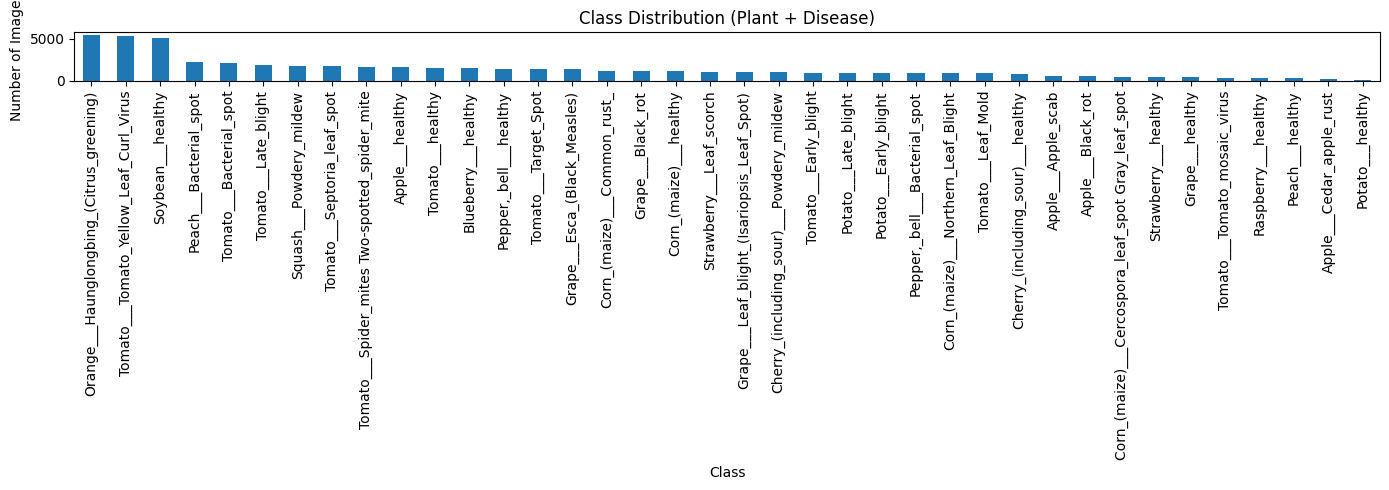

In [9]:
# visualizing data distribution
plt.figure(figsize=(14, 5))
df_color['Class'].value_counts().plot(kind="bar")
plt.title("Class Distribution (Plant + Disease)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

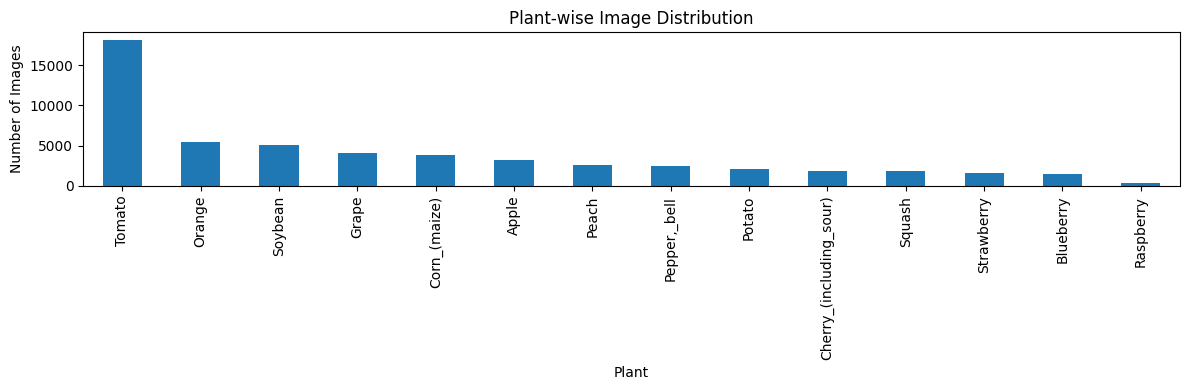

In [10]:
plt.figure(figsize=(12, 4))
df_color['plant'].value_counts().plot(kind="bar")
plt.title("Plant-wise Image Distribution")
plt.xlabel("Plant")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

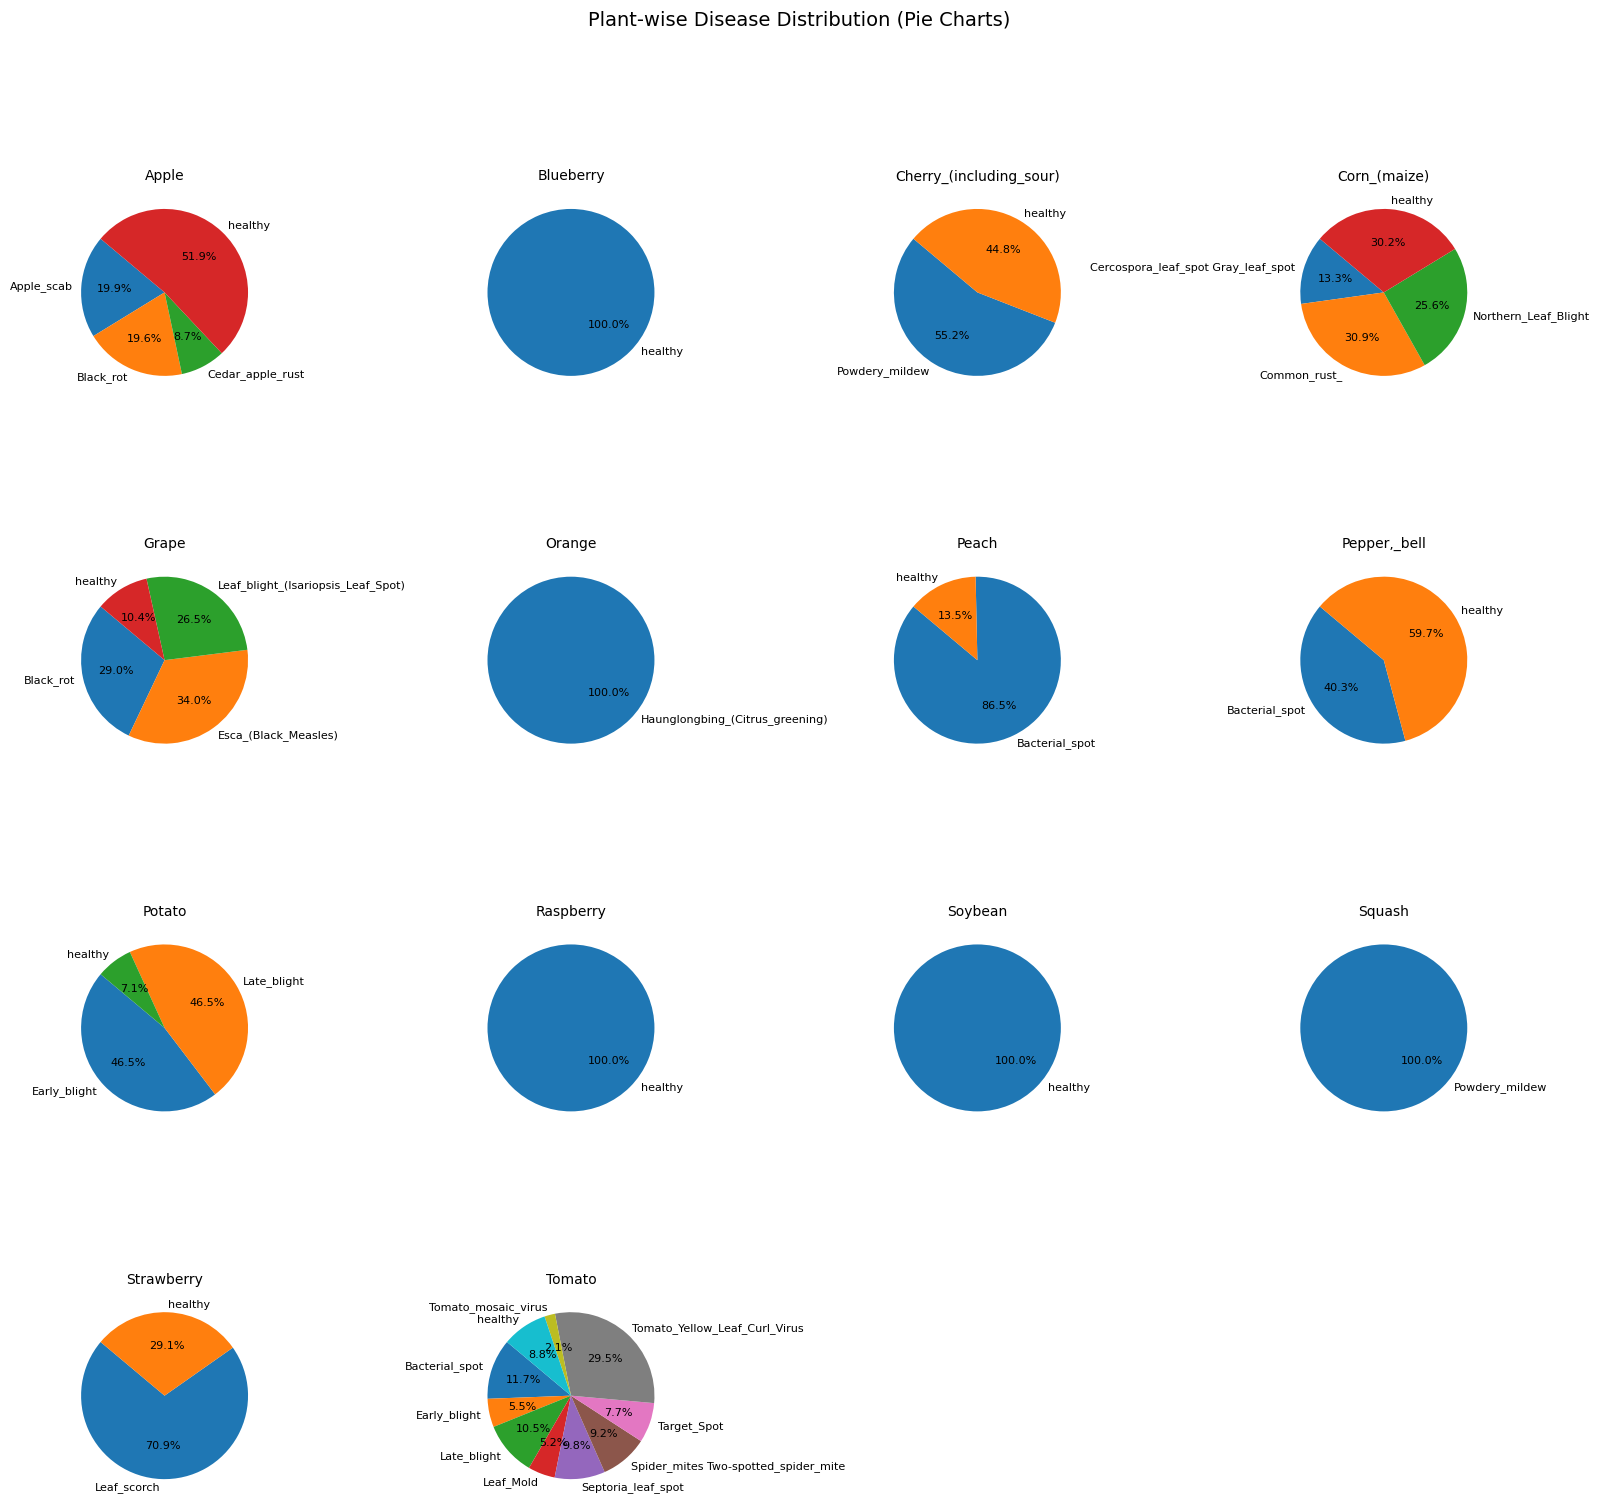

In [11]:
# Aggregate counts
plant_disease_counts = (
    df_color.groupby(['plant', 'state'])
      .size()
      .reset_index(name='count')
)

plants = sorted(df_color['plant'].unique())



# Grid size
n_cols = 4
n_rows = math.ceil(len(plants) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axes = axes.flatten()

for ax, plant in zip(axes, plants):
    data = plant_disease_counts[plant_disease_counts['plant'] == plant]
    
    ax.pie(
        data['count'],
        labels=data['state'],
        autopct='%1.1f%%',
        startangle=140,
        textprops={'fontsize': 8}
    )
    ax.set_title(plant, fontsize=10)

# Remove empty subplots
for i in range(len(plants), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("Plant-wise Disease Distribution (Pie Charts)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


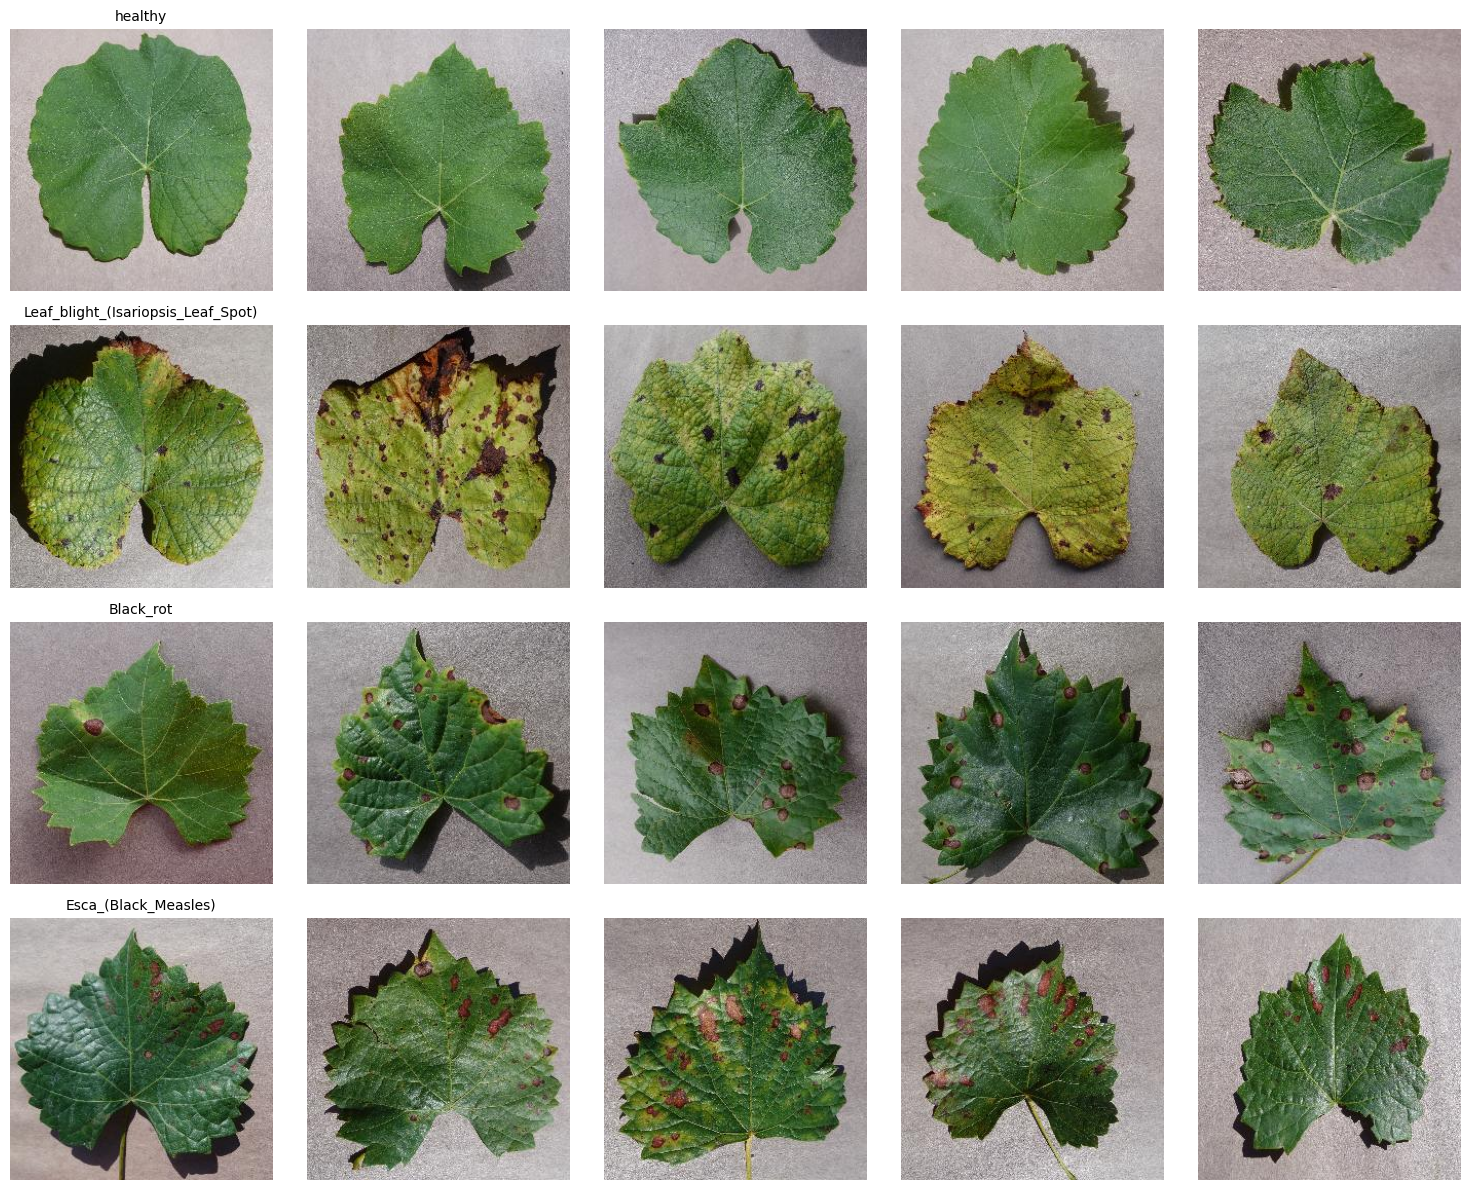

In [12]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

def sample_same_plant_different_states(df_color, plant_name="Tomato", n_images=5):
    # Filter classes belonging to the selected plant
    plant_classes = [cls for cls in df_color['Class'].unique()
                     if cls.startswith(plant_name + "___")]
    
    n_classes = len(plant_classes)
    
    fig, axes = plt.subplots(n_classes, n_images, figsize=(n_images*3, n_classes*3))
    
    for i, cls in enumerate(plant_classes):
        imgs = df_color[df_color['Class'] == cls].sample(n_images)
        
        for j, img_name in enumerate(imgs['Images']):
            img_path = Path("/kaggle/input/plantvillage-dataset/color") / cls / img_name
            img = Image.open(img_path)
            
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            
            if j == 0:
                # Show only disease/state name, not full class
                state = cls.split("___")[1]
                axes[i, j].set_title(state, fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
sample_same_plant_different_states(df_color, plant_name="Grape", n_images=5)

In [13]:
# Analyzing resolution, height and width of images
resolutions = []

sample_df = df_color.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    img_path = Path("/kaggle/input/plantvillage-dataset/color") / row['Class'] / row['Images']
    img = Image.open(img_path)
    w, h = img.size
    resolutions.append((w, h))

res_df = pd.DataFrame(resolutions, columns=['width', 'height'])

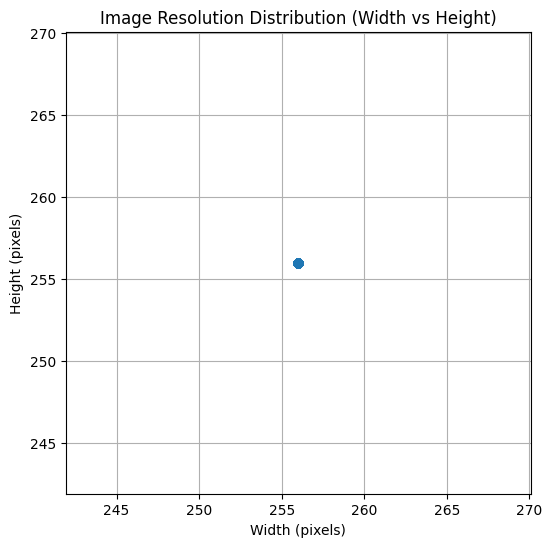

In [14]:
# Visualizing the resolution, height and width
plt.figure(figsize=(6,6))
plt.scatter(res_df['width'], res_df['height'], alpha=0.5)
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.title("Image Resolution Distribution (Width vs Height)")
plt.grid(True)
plt.show()

In [15]:
def collect_mean_rgb_plantwise(df, plant_name, images_per_state=20):
    data = []
    
    plant_df = df[df['plant'] == plant_name]

    for state in plant_df['state'].unique():
        subset = plant_df[plant_df['state'] == state].sample(
            min(images_per_state, len(plant_df[plant_df['state'] == state])),
            random_state=42
        )

        for _, row in subset.iterrows():
            img_path = (
                Path("/kaggle/input/plantvillage-dataset/color")
                / row['Class']
                / row['Images']
            )
            
            img = np.array(Image.open(img_path).convert("RGB"))

            data.append({
                "plant": plant_name,
                "state": state,
                "R": img[:, :, 0].mean(),
                "G": img[:, :, 1].mean(),
                "B": img[:, :, 2].mean()
            })

    return pd.DataFrame(data)

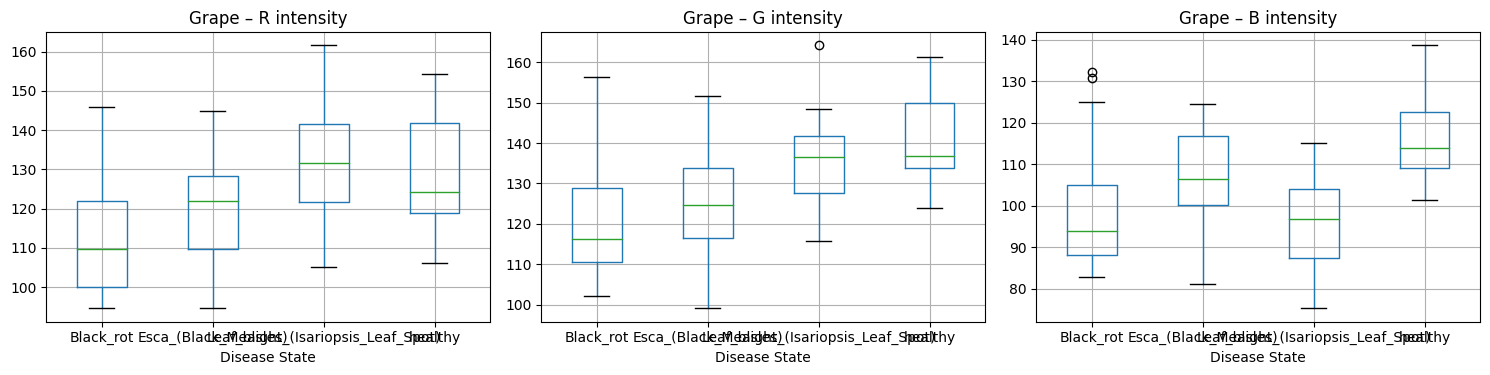

In [16]:
plant = "Grape"
rgb_plant = collect_mean_rgb_plantwise(df_color, plant)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, channel in enumerate(['R', 'G', 'B']):
    rgb_plant.boxplot(
        column=channel,
        by='state',
        ax=axes[i]
    )
    axes[i].set_title(f"{plant} – {channel} intensity")
    axes[i].set_xlabel("Disease State")

plt.suptitle("")
plt.tight_layout()
plt.show()
